# EDA — Fruit and Vegetable Disease (Healthy vs Rotten)

Notebook EDA cho bài toán phân loại **Healthy vs Rotten** của 14 loại rau củ quả (28 lớp).

**Dataset:** [Fruit and Vegetable Disease (Healthy vs Rotten)](https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten) — Kaggle, ~29.000 ảnh, 28 thư mục lớp (14 loại × 2 trạng thái).

**Mục tiêu**:
1. Kiểm tra cấu trúc thư mục & tính toàn vẹn dữ liệu đã tải về `data/raw/`.
2. Thống kê số lượng ảnh theo lớp / theo loại rau-củ-quả / theo trạng thái Healthy-Rotten → phát hiện mất cân bằng lớp (class imbalance).
3. Phân tích thuộc tính ảnh: định dạng file, ảnh lỗi, kích thước (W×H), tỉ lệ khung hình, dung lượng file, màu sắc trung bình.
4. Trực quan hoá ảnh mẫu cho từng lớp.
5. Rút ra khuyến nghị tiền xử lý cho `src/data.py` trước khi huấn luyện M1/M2/M3.

In [22]:
import os
import re
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

# Cho phép `import src.config` dù notebook được chạy từ thư mục notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, NUM_CLASSES, IMG_SIZE_M1, IMG_SIZE_M3, SEED

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

# Số ảnh lấy mẫu cho các phân tích tốn chi phí (kích thước, màu sắc) — toàn bộ
# dataset ~29k ảnh nên ta lấy mẫu ngẫu nhiên có seed cố định thay vì mở hết ảnh.
SAMPLE_SIZE = 1500

print(f"PROJECT_ROOT      = {PROJECT_ROOT}")
print(f"RAW_DATA_DIR       = {RAW_DATA_DIR}")
print(f"NUM_CLASSES (kỳ vọng) = {NUM_CLASSES}")
print(f"IMG_SIZE_M1/M3     = {IMG_SIZE_M1} / {IMG_SIZE_M3}")

PROJECT_ROOT      = c:\repo\DL-ImageClassification
RAW_DATA_DIR       = c:\repo\DL-ImageClassification\data\raw
NUM_CLASSES (kỳ vọng) = 28
IMG_SIZE_M1/M3     = 128 / 224


## 1. Đọc dữ liệu

In [24]:
dataset_path = Path(RAW_DATA_DIR)


def find_dataset_root(base_dir: Path, current_best=None, best_count=-1):
    '''Dò đệ quy để tìm thư mục chứa nhiều thư mục con nhất (kỳ vọng ~28).'''
    if not base_dir.exists():
        return base_dir, -1
    n_subdirs = sum(1 for p in base_dir.iterdir() if p.is_dir())
    if n_subdirs > best_count:
        current_best, best_count = base_dir, n_subdirs
    for p in base_dir.iterdir():
        if p.is_dir():
            current_best, best_count = find_dataset_root(p, current_best, best_count)
    return current_best, best_count


DATASET_ROOT, n_found = find_dataset_root(dataset_path)

if n_found <= 0:
    raise FileNotFoundError(
        f"Không tìm thấy thư mục lớp nào bên trong '{dataset_path}'.\n"
        "Hãy đặt dataset vào data/raw/ trước khi chạy notebook."
    )

class_dirs = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])

print(f"Dataset path             : {dataset_path}")
print(f"Thư mục dataset phát hiện : {DATASET_ROOT}")
print(f"Số thư mục lớp tìm thấy   : {len(class_dirs)} (kỳ vọng: {NUM_CLASSES})")
if len(class_dirs) != NUM_CLASSES:
    print("Số lớp khác kỳ vọng — kiểm tra lại cấu trúc data/raw.")

Dataset path             : c:\repo\DL-ImageClassification\data\raw
Thư mục dataset phát hiện : c:\repo\DL-ImageClassification\data\raw
Số thư mục lớp tìm thấy   : 28 (kỳ vọng: 28)


## 2. Danh sách 28 lớp

In [25]:
for i, d in enumerate(class_dirs, start=1):
    n_files = sum(1 for f in d.iterdir() if f.is_file())
    print(f"{i:2d}. {d.name:40s}  ({n_files} files)")

 1. Apple__Healthy                            (2438 files)
 2. Apple__Rotten                             (2930 files)
 3. Banana__Healthy                           (2000 files)
 4. Banana__Rotten                            (2800 files)
 5. Bellpepper__Healthy                       (611 files)
 6. Bellpepper__Rotten                        (591 files)
 7. Carrot__Healthy                           (620 files)
 8. Carrot__Rotten                            (580 files)
 9. Cucumber__Healthy                         (608 files)
10. Cucumber__Rotten                          (593 files)
11. Grape__Healthy                            (200 files)
12. Grape__Rotten                             (200 files)
13. Guava__Healthy                            (200 files)
14. Guava__Rotten                             (200 files)
15. Jujube__Healthy                           (200 files)
16. Jujube__Rotten                            (200 files)
17. Mango__Healthy                            (1813 files)
18. Mango

## 3. Xây dựng bảng catalog toàn bộ ảnh

Duyệt toàn bộ `RAW_DATA_DIR`, tách tên thư mục lớp thành `category` (loại rau/củ/quả) và `status` (Healthy/Rotten) — không giả định ký tự phân cách cụ thể (`__`, `_`, `-`, khoảng trắng), chỉ dựa vào từ khoá `healthy`/`rotten` để tương thích với nhiều kiểu đặt tên khác nhau của bản zip Kaggle.

In [26]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}


def parse_class_name(folder_name: str):
    lower = folder_name.lower()
    if "healthy" in lower or "fresh" in lower:
        status = "Healthy"
    elif "rotten" in lower or re.search(r"\brot\b", lower):
        status = "Rotten"
    else:
        status = "Unknown"

    category = re.sub(r"(?i)healthy|rotten|fresh|\brot\b", " ", folder_name)
    category = re.sub(r"[_\-]+", " ", category).strip()
    category = " ".join(category.split())
    return (category.title() if category else folder_name), status


records = []
for class_dir in class_dirs:
    category, status = parse_class_name(class_dir.name)
    for fp in class_dir.rglob("*"):
        if fp.is_file() and fp.suffix.lower() in IMAGE_EXTENSIONS:
            records.append(
                {
                    "filepath": str(fp),
                    "class_name": class_dir.name,
                    "category": category,
                    "status": status,
                    "extension": fp.suffix.lower(),
                    "file_size_kb": fp.stat().st_size / 1024,
                }
            )

df = pd.DataFrame(records)
print(f"Tổng số ảnh quét được: {len(df):,}")
df.head()

Tổng số ảnh quét được: 29,291


,filepath,class_name,category,status,extension,file_size_kb
0,c:\repo\DL-ImageClassification\data\raw\Apple_...,Apple__Healthy,Apple,Healthy,.jpg,2904.308594
1,c:\repo\DL-ImageClassification\data\raw\Apple_...,Apple__Healthy,Apple,Healthy,.png,226.740234
2,c:\repo\DL-ImageClassification\data\raw\Apple_...,Apple__Healthy,Apple,Healthy,.jpg,815.652344
3,c:\repo\DL-ImageClassification\data\raw\Apple_...,Apple__Healthy,Apple,Healthy,.jpg,678.750000
4,c:\repo\DL-ImageClassification\data\raw\Apple_...,Apple__Healthy,Apple,Healthy,.jpg,742.142578


## 4. Thống kê tổng quan

In [9]:
n_categories = df["category"].nunique()
n_unknown = (df["status"] == "Unknown").sum()

print(f"Số loại rau/củ/quả (category) : {n_categories} (kỳ vọng: 14)")
print(f"Số lớp (class_name)           : {df['class_name'].nunique()} (kỳ vọng: {NUM_CLASSES})")
print(f"Ảnh có status không xác định  : {n_unknown}")
print()
print("Phân bố theo trạng thái:")
print(df["status"].value_counts())

if n_unknown:
    print("\n⚠️  Một số thư mục không parse được Healthy/Rotten — kiểm tra lại:")
    print(df.loc[df["status"] == "Unknown", "class_name"].unique())

Số loại rau/củ/quả (category) : 14 (kỳ vọng: 14)
Số lớp (class_name)           : 28 (kỳ vọng: 28)
Ảnh có status không xác định  : 0

Phân bố theo trạng thái:
status
Rotten     15504
Healthy    13787
Name: count, dtype: int64


## 5. Số lượng ảnh theo từng lớp (28 lớp)

Dataset bị mất cân bằng khá rõ: lớp ít nhất có 200 ảnh, lớp nhiều nhất có 2.930 ảnh, tương ứng tỉ lệ `14,65x`. Khi huấn luyện nên cân nhắc class weights hoặc sampler để các lớp ít ảnh không bị bỏ qua.

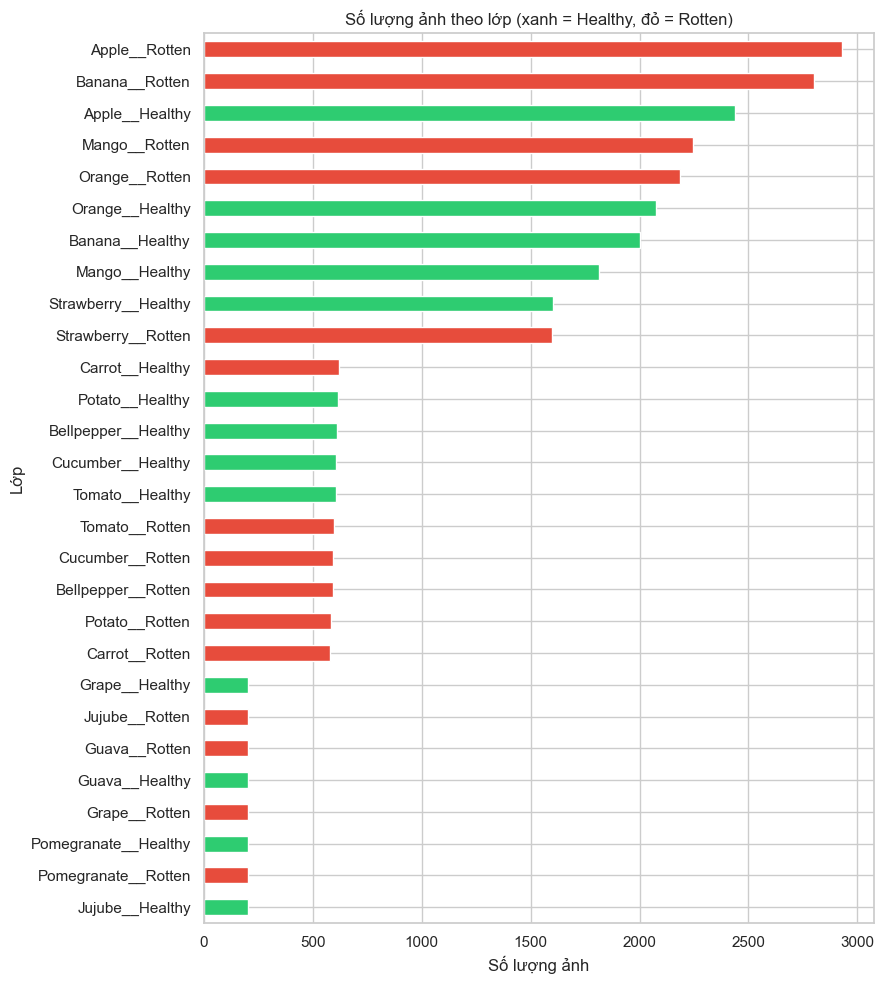

Lớp ít ảnh nhất : Jujube__Healthy (200 ảnh)
Lớp nhiều ảnh nhất: Apple__Rotten (2930 ảnh)
Tỉ lệ mất cân bằng (max/min): 14.65x


In [10]:
class_counts = df["class_name"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 10))
colors = ["#e74c3c" if "rot" in c.lower() else "#2ecc71" for c in class_counts.index]
class_counts.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Số lượng ảnh")
ax.set_ylabel("Lớp")
ax.set_title("Số lượng ảnh theo lớp (xanh = Healthy, đỏ = Rotten)")
plt.tight_layout()
plt.show()

print("Lớp ít ảnh nhất :", class_counts.idxmin(), f"({class_counts.min()} ảnh)")
print("Lớp nhiều ảnh nhất:", class_counts.idxmax(), f"({class_counts.max()} ảnh)")
print(f"Tỉ lệ mất cân bằng (max/min): {class_counts.max() / class_counts.min():.2f}x")

## 6. So sánh Healthy vs Rotten theo từng loại rau/củ/quả

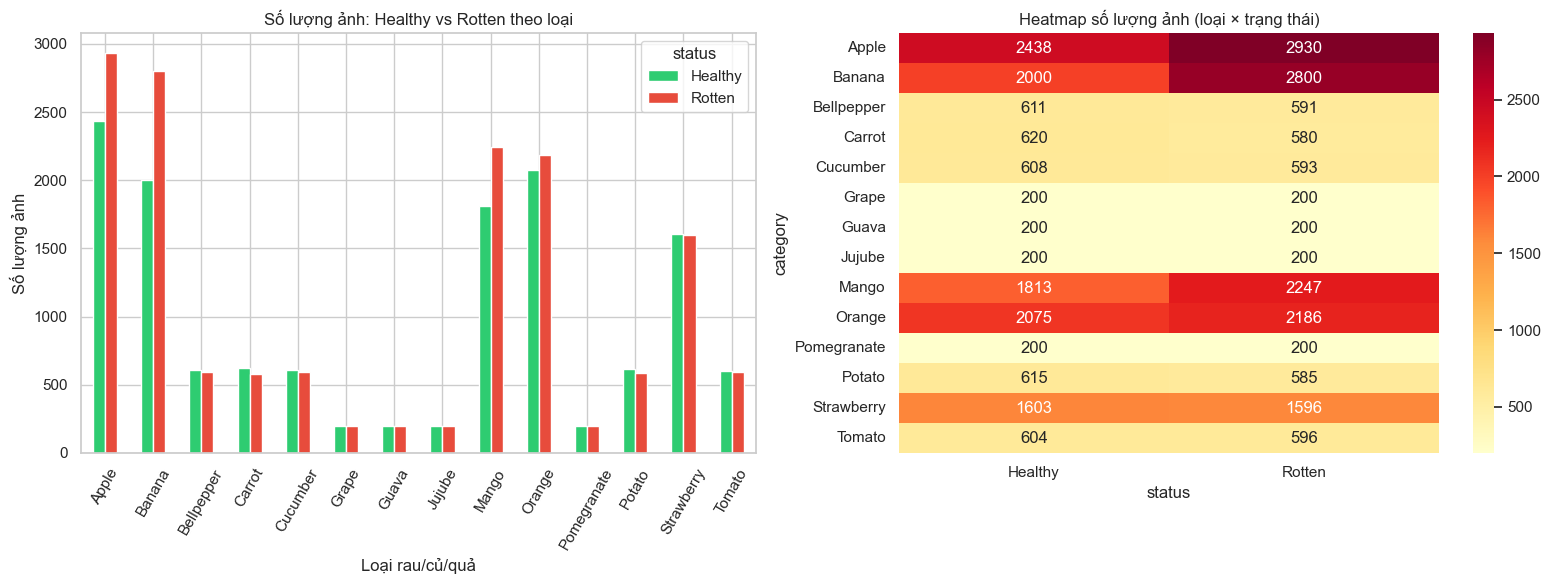

status,Healthy,Rotten,total,healthy_ratio
category,,,,
Apple,2438,2930,5368,0.45
Banana,2000,2800,4800,0.42
Orange,2075,2186,4261,0.49
Mango,1813,2247,4060,0.45
Strawberry,1603,1596,3199,0.50
Bellpepper,611,591,1202,0.51
Cucumber,608,593,1201,0.51
Carrot,620,580,1200,0.52
Potato,615,585,1200,0.51


In [11]:
pivot = df.pivot_table(index="category", columns="status", values="filepath", aggfunc="count", fill_value=0)
pivot = pivot.reindex(columns=[c for c in ["Healthy", "Rotten", "Unknown"] if c in pivot.columns])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot.plot(kind="bar", stacked=False, ax=axes[0], color=["#2ecc71", "#e74c3c", "#95a5a6"])
axes[0].set_title("Số lượng ảnh: Healthy vs Rotten theo loại")
axes[0].set_xlabel("Loại rau/củ/quả")
axes[0].set_ylabel("Số lượng ảnh")
axes[0].tick_params(axis="x", rotation=60)

sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Heatmap số lượng ảnh (loại × trạng thái)")

plt.tight_layout()
plt.show()

pivot["total"] = pivot.sum(axis=1)
if "Healthy" in pivot.columns and "Rotten" in pivot.columns:
    pivot["healthy_ratio"] = (pivot["Healthy"] / pivot["total"]).round(2)
pivot.sort_values("total", ascending=False)

## 7. Định dạng file & kiểm tra ảnh lỗi

Dataset gồm chủ yếu `.jpg` (17.384 ảnh) và `.png` (11.813 ảnh), ngoài ra có 80 file `.jpeg` và 14 file `.webp`. Kiểm tra bằng `PIL.Image.verify()` cho thấy không có ảnh lỗi trong 29.291 ảnh.

In [12]:
print("Phân bố định dạng file:")
print(df["extension"].value_counts())
print()

corrupt_files = []
for i, fp in enumerate(df["filepath"]):
    try:
        with Image.open(fp) as im:
            im.verify()
    except (UnidentifiedImageError, OSError) as e:
        corrupt_files.append((fp, str(e)))
    if (i + 1) % 5000 == 0:
        print(f"  ...đã kiểm tra {i + 1:,}/{len(df):,} ảnh")

print(f"\nSố ảnh lỗi/không đọc được: {len(corrupt_files)}")
for fp, err in corrupt_files[:20]:
    print(f"  - {fp}: {err}")

Phân bố định dạng file:
extension
.jpg     17384
.png     11813
.jpeg       80
.webp       14
Name: count, dtype: int64

  ...đã kiểm tra 5,000/29,291 ảnh
  ...đã kiểm tra 10,000/29,291 ảnh
  ...đã kiểm tra 15,000/29,291 ảnh
  ...đã kiểm tra 20,000/29,291 ảnh
  ...đã kiểm tra 25,000/29,291 ảnh

Số ảnh lỗi/không đọc được: 0


## 8. Kích thước ảnh (width × height, tỉ lệ khung hình)

Trên mẫu 1.500 ảnh, kích thước trung vị là `301×258` pixel và tỉ lệ khung hình trung vị là `1,00`. Kích thước ảnh dao động từ `100×100` đến `5616×4160`, vì vậy pipeline cần resize; nên ưu tiên crop hoặc giữ tỉ lệ trước khi đưa ảnh về kích thước `128` hoặc `224`.

In [13]:
valid_df = df[~df["filepath"].isin([fp for fp, _ in corrupt_files])].reset_index(drop=True)
sample_df = valid_df.sample(n=min(SAMPLE_SIZE, len(valid_df)), random_state=SEED).copy()

widths, heights, modes = [], [], []
for fp in sample_df["filepath"]:
    with Image.open(fp) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)
        modes.append(im.mode)

sample_df["width"] = widths
sample_df["height"] = heights
sample_df["aspect_ratio"] = sample_df["width"] / sample_df["height"]
sample_df["color_mode"] = modes

print(f"Số ảnh lấy mẫu để phân tích kích thước/màu sắc: {len(sample_df)}")
sample_df[["width", "height", "aspect_ratio"]].describe()

Số ảnh lấy mẫu để phân tích kích thước/màu sắc: 1500


,width,height,aspect_ratio
count,1500.000000,1500.000000,1500.000000
mean,589.160667,531.278000,1.127041
std,808.241170,735.344903,0.251023
min,100.000000,100.000000,0.382372
25%,224.000000,224.000000,1.000000
50%,301.000000,258.000000,1.000000
75%,480.000000,402.000000,1.240310
max,5616.000000,4160.000000,2.862595


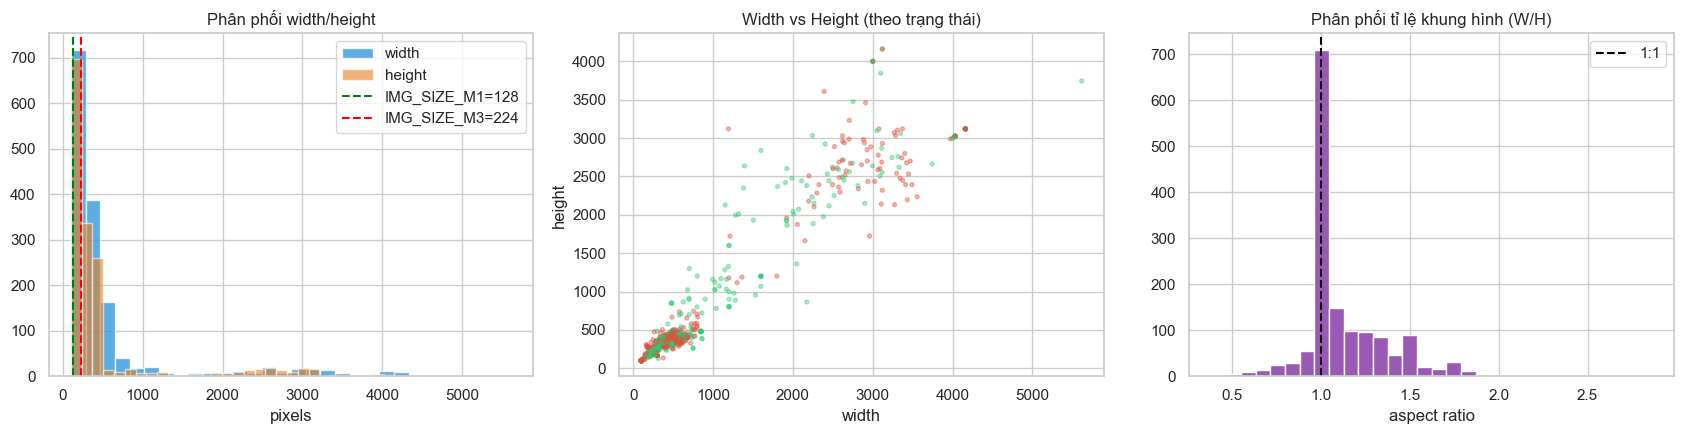

Số kích thước (width,height) duy nhất trong mẫu: 706
Các chế độ màu (color_mode) xuất hiện: {'RGB': 1456, 'RGBA': 43, 'P': 1}


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(sample_df["width"], bins=30, color="#3498db", alpha=0.8, label="width")
axes[0].hist(sample_df["height"], bins=30, color="#e67e22", alpha=0.6, label="height")
axes[0].axvline(IMG_SIZE_M1, color="green", linestyle="--", label=f"IMG_SIZE_M1={IMG_SIZE_M1}")
axes[0].axvline(IMG_SIZE_M3, color="red", linestyle="--", label=f"IMG_SIZE_M3={IMG_SIZE_M3}")
axes[0].set_title("Phân phối width/height")
axes[0].set_xlabel("pixels")
axes[0].legend()

axes[1].scatter(sample_df["width"], sample_df["height"], s=8, alpha=0.4,
                 c=sample_df["status"].map({"Healthy": "#2ecc71", "Rotten": "#e74c3c", "Unknown": "#95a5a6"}))
axes[1].set_title("Width vs Height (theo trạng thái)")
axes[1].set_xlabel("width")
axes[1].set_ylabel("height")

axes[2].hist(sample_df["aspect_ratio"], bins=30, color="#9b59b6")
axes[2].axvline(1.0, color="black", linestyle="--", label="1:1")
axes[2].set_title("Phân phối tỉ lệ khung hình (W/H)")
axes[2].set_xlabel("aspect ratio")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Số kích thước (width,height) duy nhất trong mẫu:", sample_df[["width", "height"]].drop_duplicates().shape[0])
print("Các chế độ màu (color_mode) xuất hiện:", sample_df["color_mode"].value_counts().to_dict())

## 9. Dung lượng file ảnh

Dung lượng file có độ phân tán lớn: trung vị khoảng `65 KB`, trung bình khoảng `174 KB`, nhưng có file lên tới khoảng `9,5 MB`. Phần lớn ảnh có dung lượng nhỏ, tuy nhiên nên đọc dữ liệu theo batch để tránh tốn nhiều bộ nhớ.

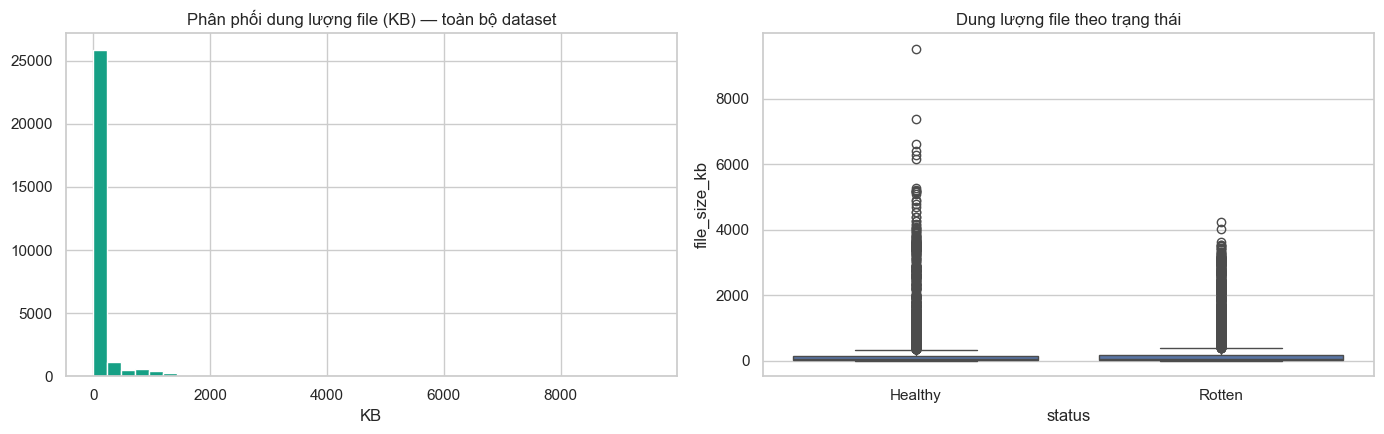

count    29291.000000
mean       173.565797
std        423.911847
min          1.051758
25%          6.792969
50%         65.044922
75%        151.560547
max       9512.117188
Name: file_size_kb, dtype: float64

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(df["file_size_kb"], bins=40, color="#16a085")
axes[0].set_title("Phân phối dung lượng file (KB) — toàn bộ dataset")
axes[0].set_xlabel("KB")

sns.boxplot(data=df, x="status", y="file_size_kb", ax=axes[1],
            order=[s for s in ["Healthy", "Rotten", "Unknown"] if s in df["status"].unique()])
axes[1].set_title("Dung lượng file theo trạng thái")

plt.tight_layout()
plt.show()

df["file_size_kb"].describe()

## 10. Màu sắc trung bình theo trạng thái

Trong mẫu 1.500 ảnh, nhóm Rotten có giá trị RGB trung bình và độ sáng nhỉnh hơn nhóm Healthy. Đây là tín hiệu tham khảo, chưa đủ để kết luận về đặc trưng phân loại; augmentation màu vẫn cần thiết để mô hình học thêm hình dạng và kết cấu.

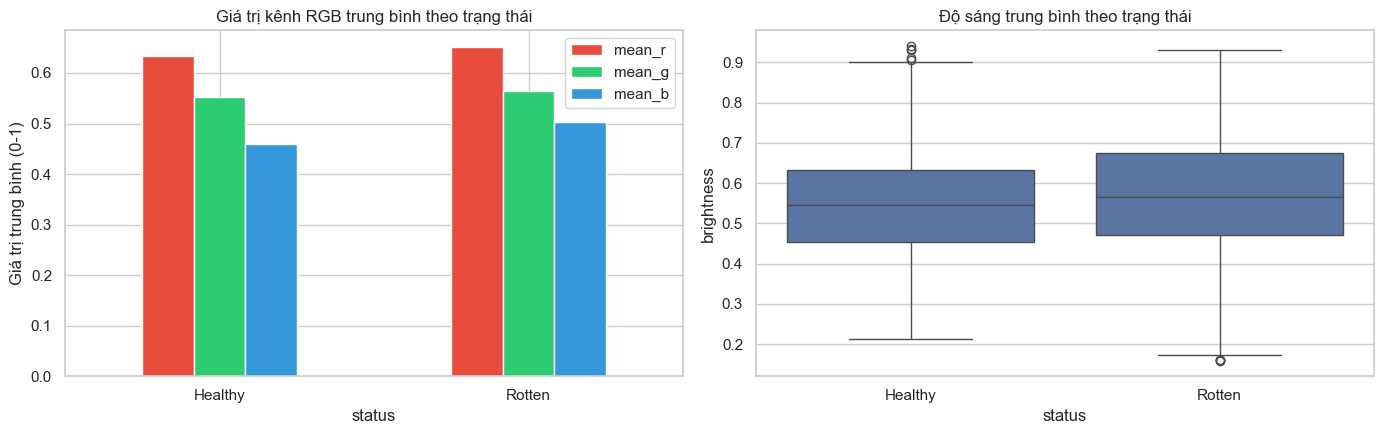

In [16]:
mean_r, mean_g, mean_b, brightness = [], [], [], []
for fp in sample_df["filepath"]:
    with Image.open(fp) as im:
        arr = np.asarray(im.convert("RGB").resize((64, 64)), dtype=np.float32) / 255.0
    mean_r.append(arr[..., 0].mean())
    mean_g.append(arr[..., 1].mean())
    mean_b.append(arr[..., 2].mean())
    brightness.append(arr.mean())

sample_df["mean_r"] = mean_r
sample_df["mean_g"] = mean_g
sample_df["mean_b"] = mean_b
sample_df["brightness"] = brightness

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sample_df.groupby("status")[["mean_r", "mean_g", "mean_b"]].mean().plot(
    kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71", "#3498db"]
)
axes[0].set_title("Giá trị kênh RGB trung bình theo trạng thái")
axes[0].set_ylabel("Giá trị trung bình (0-1)")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(data=sample_df, x="status", y="brightness", ax=axes[1],
            order=[s for s in ["Healthy", "Rotten", "Unknown"] if s in sample_df["status"].unique()])
axes[1].set_title("Độ sáng trung bình theo trạng thái")

plt.tight_layout()
plt.show()

## 11. Ảnh mẫu trực quan (Healthy vs Rotten)

Hiển thị một số ảnh đại diện cho các nhóm Healthy và Rotten để kiểm tra nhanh chất lượng ảnh và sự khác biệt trực quan giữa hai trạng thái.

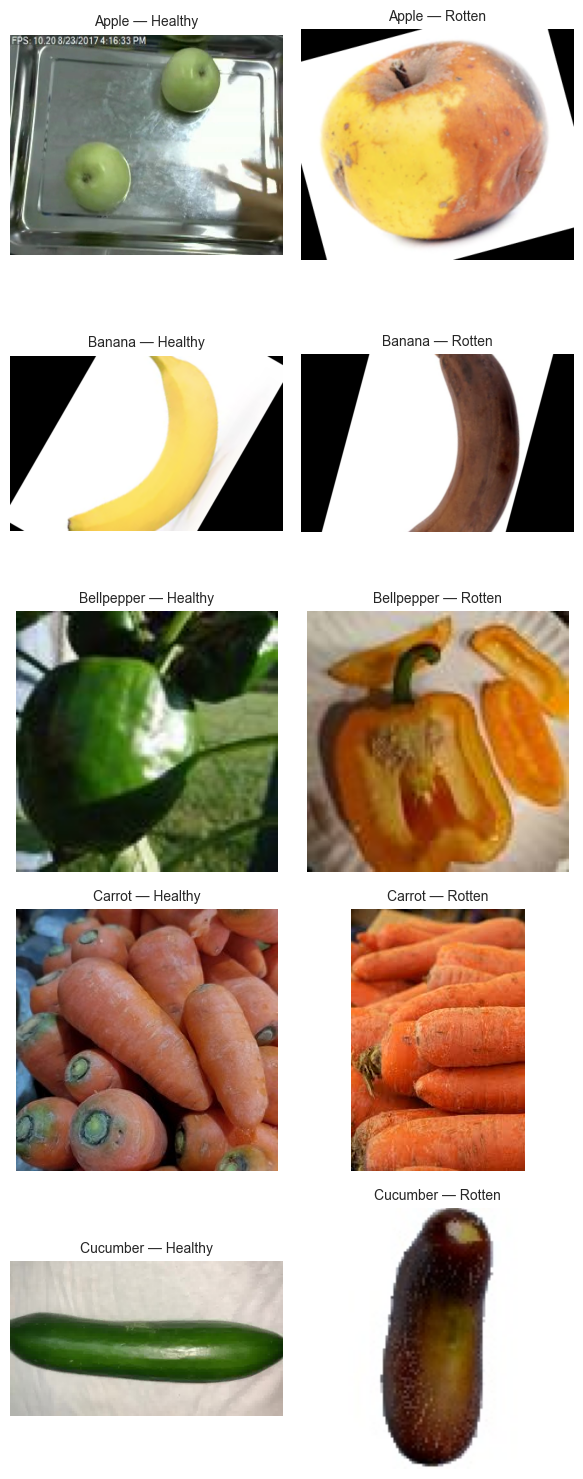

In [17]:
def plot_sample_grid(dataframe, categories, n_per_cell=1, seed=SEED):
    rng = random.Random(seed)
    statuses = ["Healthy", "Rotten"]
    fig, axes = plt.subplots(len(categories), len(statuses), figsize=(6, 3 * len(categories)))
    if len(categories) == 1:
        axes = axes.reshape(1, -1)

    for i, cat in enumerate(categories):
        for j, status in enumerate(statuses):
            subset = dataframe[(dataframe["category"] == cat) & (dataframe["status"] == status)]
            ax = axes[i, j]
            if len(subset) == 0:
                ax.axis("off")
                continue
            fp = rng.choice(subset["filepath"].tolist())
            with Image.open(fp) as im:
                ax.imshow(im.convert("RGB"))
            ax.set_title(f"{cat} — {status}", fontsize=10)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


sample_categories = sorted(df["category"].unique())[:5]
plot_sample_grid(df, sample_categories)

## 12. Lưu bảng catalog để tái sử dụng

Catalog gồm 29.291 dòng, chứa đường dẫn ảnh trong `data/raw/`, tên lớp, category, status, định dạng và dung lượng file. Kết quả được lưu tại `data/processed/eda_catalog.csv`.

In [18]:
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
catalog_path = os.path.join(PROCESSED_DATA_DIR, "eda_catalog.csv")
df.drop(columns=[]).to_csv(catalog_path, index=False)
print(f"Đã lưu catalog ({len(df):,} dòng) vào: {catalog_path}")

Đã lưu catalog (29,291 dòng) vào: c:\repo\DL-ImageClassification\data\processed\eda_catalog.csv


## 13. Tóm tắt & khuyến nghị tiền xử lý

- Dataset có đủ 28 lớp và 29.291 ảnh; không phát hiện ảnh lỗi bằng `PIL.Image.verify()`.
- Phân bố lớp mất cân bằng mạnh (`14,65x` giữa lớp nhiều và lớp ít ảnh), nên dùng class weights hoặc weighted sampler khi huấn luyện.
- Ảnh có nhiều kích thước khác nhau, từ `100×100` đến `5616×4160`. Nên resize về `128×128` cho M1/M2 và `224×224` cho M3; dùng crop hoặc padding để hạn chế méo ảnh.
- Ảnh Rotten trong mẫu có RGB trung bình cao hơn Healthy một chút và độ sáng trung vị cũng nhỉnh hơn. Không nên để mô hình chỉ học màu sắc, nên bổ sung augmentation như `ColorJitter`.
- Catalog đã được lưu tại `data/processed/eda_catalog.csv` để dùng cho bước chia train/validation/test.